<h4>定义 Определение</h4>

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import floor
import csv

<h4>在此定义输入维度和目标维度</h4>
需要将测试集里面的Very Low转化成very_low

In [126]:
type = {"very_low":0,"Low":1,"Middle":2,"High":3}#将类型变为数字 Преобразование типов в числа
name = ["very_low","Low","Middle","High"]#将数字变为类型 Преобразование чисел в типы
num_Target = len(name)
dim_Input = 5

<h4>读取文件并把向量数字化 Чтение файла и векторизация данных</h4>
需要依据情况修改sep

In [127]:
file = 'train.csv'
df = pd.read_csv(file, encoding='utf-8',sep=',')
array = df.to_numpy()
for j in range(len(array)):
    array[j][dim_Input] = type[array[j][dim_Input]]

file = 'test.csv'
df = pd.read_csv(file, encoding='utf-8',sep=',')
arrayTest = df.to_numpy()
for j in range(len(arrayTest)):
    arrayTest[j][dim_Input] = type[arrayTest[j][dim_Input]]

<h4>提取初始以及目标向量 Извлечение начальных и целевых векторов</h4>

In [128]:
X = array[:, :dim_Input]
Y = array[:, dim_Input]
X_test = arrayTest[:, :dim_Input]
Y_test = arrayTest[:, dim_Input]
num_INP = len(array)
probability = []#将类型转化为概率
num_INP = len(array)
matrixTarget = np.eye(num_Target)
for i in range(num_INP):
    probability.append(matrixTarget[Y[i]])

#min-max归一化避免非线性模型数值溢出
X_min = X.min(axis=0)
X_max = X.max(axis=0)
X = (X - X_min) / (X_max - X_min + 1e-8)

<h4>可视化（AI生成） Визуализация(AI-gen)</h4>

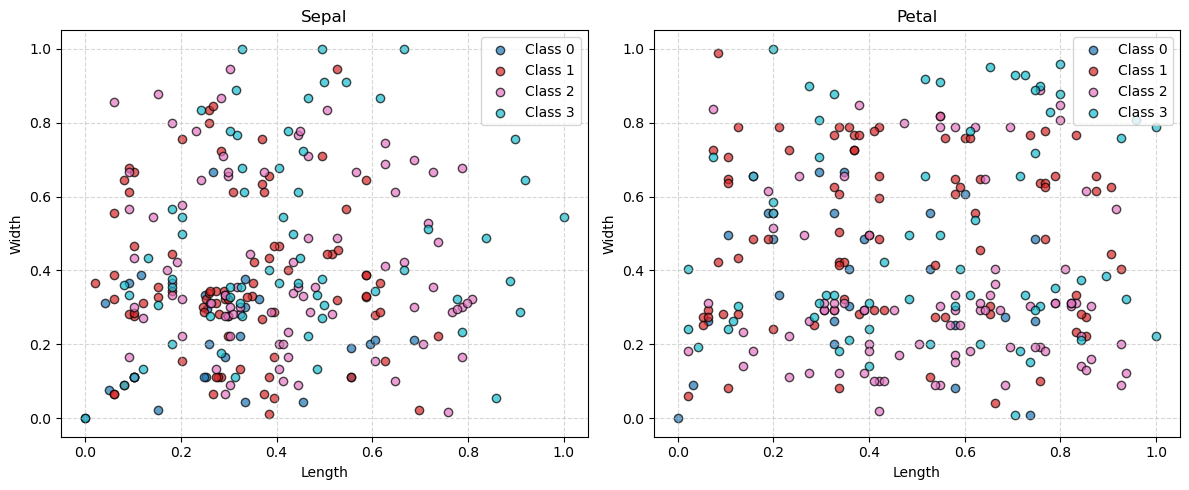

In [129]:
unique_labels = np.unique(Y)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for label, color in zip(unique_labels, colors):
    mask = (Y == label)
    ax1.scatter(X[mask, 0], X[mask, 1], c=[color], label=f'Class {label}', edgecolors='k', alpha=0.7)
ax1.set_xlabel('Length')
ax1.set_ylabel('Width')
ax1.set_title('Sepal')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

for label, color in zip(unique_labels, colors):
    mask = (Y == label)
    ax2.scatter(X[mask, 2], X[mask, 3], c=[color], label=f'Class {label}', edgecolors='k', alpha=0.7)
ax2.set_xlabel('Length')
ax2.set_ylabel('Width')
ax2.set_title('Petal')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

<h4>在下面定义容许误差ε，最大许可训练次数maxTime以及训练率α</h4>

In [130]:
epsilon = 0.01*num_INP*3#定义容许误差 Определение допустимой погрешности
maxTime = int(2E5)
alpha = 1E-3

<h4>多项式类</h4>

In [131]:
class polinomVector:
    def __init__(self, p, q):#初始化以及变量定义 p为多项式次数，q为向量维度
        self.item=[]
        self.p = p
        self.q = q
        self.constant = 0
        self.item = np.zeros((p, q), dtype=float)

    def save(self, filename):#保存
        flat_coeff = self.item.flatten().tolist()
        str_coeff = [str(x) for x in flat_coeff]
        with open(filename, 'w') as f:
            f.write(' '.join(str_coeff) + ' ' + str(self.constant))

    def load(self, filename):#读取
        with open(filename, 'r') as f:
            nums = list(map(float, f.readline().split()))
        expected_len = self.p * self.q + 1
        if len(nums) != expected_len:
            raise ValueError(f"数据数量错误：期望 {expected_len}，实际 {len(nums)}")
        self.item = np.array(nums[:self.p*self.q]).reshape(self.p, self.q)
        self.constant = nums[-1]

    def func(self, inpvec):#幂函数多项式模型
        out = self.constant
        if len(inpvec) != self.q:
            raise Exception("维度错误")
        powers = np.array([inpvec[i] ** (j+1) for i in range(self.q) for j in range(self.p)]).reshape(self.q, self.p).T
        out = self.constant + np.sum(powers * self.item)
        return out
    
    def err(self, inpvec,target):
        if len(inpvec) != self.q:
            print(inpvec)
            print(self.q)
            raise Exception("维度错误")
        return (self.func(inpvec)-target)**2
    
    def total_err(self,idx):#总误差 Общая погрешность
        out=0
        for i in range(num_INP):
            out+=(self.err(X[i],probability[i][idx]))
        return out

    def train(self, alpha, maxtimes, epsilon, idx):
        global times
        gradient = np.zeros((self.p, self.q), dtype=float)
        consta = 0
        for index in range(maxtimes):
            for j in range(num_INP):
                temp = 2*(self.func(X[j])-probability[j][idx])
                consta += temp
                for i in range(self.p):
                    for k in range(self.q):
                        gradient[i][k] += temp*X[j][k]**(i+1)
            self.item += -alpha * gradient
            self.constant += -alpha * consta
            times += 1
            if  self.total_err(idx) < epsilon:
                break       

coeff = []
for i in range(num_Target):
    coeff.append(polinomVector(3,dim_Input))

def save(coeff):
    with open('coeff.txt', 'w') as f:
        for obj in coeff:
            # 将系数矩阵展平为列表并转换为字符串
            flat_coeff = obj.item.flatten().tolist()
            str_coeff = [str(x) for x in flat_coeff]
            # 写入一行：系数 + 空格 + 常数
            f.write(' '.join(str_coeff) + ' ' + str(obj.constant) + '\n')

def load(coeff):
    try:
        with open('coeff.txt', 'r') as f:
            lines = f.readlines()
    except FileNotFoundError:
        raise FileNotFoundError("coeff.txt 文件不存在")

    if len(lines) != len(coeff):
        raise ValueError(f"文件行数 ({len(lines)}) 与对象数量 ({len(coeff)}) 不匹配")

    for obj, line in zip(coeff, lines):
        # 解析当前行
        parts = line.strip().split()
        if not parts:
            raise ValueError("文件包含空行")

        nums = list(map(float, parts))
        expected_len = obj.p * obj.q + 1
        if len(nums) != expected_len:
            raise ValueError(
                f"数据数量错误：对象 (p={obj.p}, q={obj.q}) 期望 {expected_len} 个数值，"
                f"但该行实际有 {len(nums)} 个"
            )

        # 前 p*q 个数值为系数矩阵展平值
        obj.item = np.array(nums[:obj.p * obj.q]).reshape(obj.p, obj.q)
        # 最后一个数值为常数项
        obj.constant = nums[-1]

<h4>选择数据来源，输入0重新输入，输入其他数字使用保存的参数 Выберите источник данных, введите 0 для повторного ввода, введите другую цифру для использования сохраненных параметров</h4>

In [132]:
mode = int(input())#0为重置，1为继续训练，其他数字为跳过训练 0 - сброс, 1 - продолжение обучения, другие числа - пропуск обучения
if mode==0:
    pass
else:
     load(coeff)

<h4>训练及模型 Обучение и модель</h4>

In [133]:
def roughlyEnoughInt(inp):#四舍五入 Округление
    if inp-floor(inp) <0.5:
        if inp<0:
            return 0
        else:
            return floor(inp)
    else:
        if floor(inp)+1>2:
            return 2
        else:
            return floor(inp)+1

def predict(inpvec):#结果模型 Итоговая модель
    proba = []
    for i in range(len(coeff)):
        proba.append(coeff[i].func(inpvec))
    tmp = 0
    maxim = max(proba)
    tmp = proba.index(maxim)
    return [tmp,proba]

print("训练前总误差")#Русский: Общая погрешность до обучения
beginerr=0
for i in range(len(coeff)):
    beginerr+=coeff[i].total_err(i)
print(beginerr)
if mode == 1 or (mode ==0):
    times = 0
    for i in range(len(coeff)):
        coeff[i].train(alpha,maxTime,epsilon,i)
    print("训练后总误差")#Русский: Общая погрешность после обучения
    enderr=0
    for i in range(len(coeff)):
        enderr+=coeff[i].total_err(i)
    print(enderr)
    print("训练次数")#Русский:
    print(times)
    print("平均每次训练减小误差")#Русский:
    print((beginerr-enderr)/times)
else:
    print("未进行训练")#Русский: Обучение не проводилось
save(coeff)

训练前总误差
109.13173268006618
训练后总误差
95.17634002205581
训练次数
800000
平均每次训练减小误差
1.744424082251296e-05


<h4>测试模型 Тест Моделя</h4>

In [134]:
output_file = 'predictions.csv'  # 输出文件
predicted_names = []
outX1, outX2, outX3, outX4 = [], [], [], []  # 假设只有4个特征
probabil = []  # 存储每个样本的概率

# 假设 X 是输入数据，num_INP 是样本数
for i in range(num_INP):
    outX1.append(X[i][0])
    outX2.append(X[i][1])
    outX3.append(X[i][2])
    outX4.append(X[i][3])
    pred_res = predict(X[i])          # 预测结果：(数字标签, 概率列表)
    pred_num = pred_res[0]             # 数字标签 0,1,2,3
    prob_list = pred_res[1]             # 概率列表，长度 = num_Target
    probabil.append(prob_list)
    pred_name = name[pred_num]          # 转换为类别名称
    predicted_names.append(pred_name)

# 动态收集所有 outX 变量（按序号排序）
outX_vars = []
j = 1
while True:
    var_name = f'outX{j}'
    if var_name in globals():
        outX_vars.append(globals()[var_name])
        j += 1
    else:
        break

if not outX_vars:
    raise ValueError("未找到任何 outX 变量，请检查数据")

# 将多个列表按行组合成二维数组 features
features = [list(row) for row in zip(*outX_vars)]

# 写入 CSV
with open(output_file, 'w', newline='') as f:
    writer = csv.writer(f)
    # 表头：特征列（通用名） + 预测类别 + 各类别概率（使用 name 列表）
    header = [f'Feature_{i+1}' for i in range(len(outX_vars))] + ['Predicted_Type'] + name
    writer.writerow(header)
    
    for i, name_label in enumerate(predicted_names):
        # 一行数据：特征值 + 预测类别 + 概率值
        row = features[i] + [name_label] + probabil[i]
        writer.writerow(row)

print(f"预测完成，结果已保存至 {output_file}")

预测完成，结果已保存至 predictions.csv


<h4>准确度检查 Проверка точности</h4>

In [135]:
T, F = np.zeros(num_Target), np.zeros(num_Target)
for i in range(num_INP):
    t = type[predicted_names[i]]
    if 0 <= t < num_Target:
        if t == Y[i]:
            T[t] += 1
        else:
            F[t] += 1
    else:
        # 可选：处理无效的类型值，例如忽略或报错
        pass

allT = np.sum(T)
allF = np.sum(F)
accruacy = allT/(allT+allF)
print(f"准确率：{accruacy*100:.2f}%") 
for i in range(len(T)):
    print(f"{name[i]}命中次数：{T[i]}，未命中次数{F[i]}") 

准确率：87.98%
very_low命中次数：18.0，未命中次数2.0
Low命中次数：74.0，未命中次数20.0
Middle命中次数：73.0，未命中次数7.0
High命中次数：62.0，未命中次数2.0


<h4>测试</h4>

In [136]:
output_file = 'predictionsTest.csv'  # 输出文件
predicted_names = []
probabil = []  # 存储每个样本的概率

# 假设 X 是输入数据，num_INP 是样本数
for i in range(len(X_test)):
    pred_res = predict(X_test[i])          # 预测结果：(数字标签, 概率列表)
    pred_num = pred_res[0]             # 数字标签 0,1,2,3
    prob_list = pred_res[1]             # 概率列表，长度 = num_Target
    probabil.append(prob_list)
    pred_name = name[pred_num]          # 转换为类别名称
    predicted_names.append(pred_name)

# 动态收集所有 outX 变量（按序号排序）
outX_vars = []
j = 1
while True:
    var_name = f'outX{j}'
    if var_name in globals():
        outX_vars.append(globals()[var_name])
        j += 1
    else:
        break

if not outX_vars:
    raise ValueError("未找到任何 outX 变量，请检查数据")

# 将多个列表按行组合成二维数组 features
features = [list(row) for row in zip(*outX_vars)]

# 写入 CSV
with open(output_file, 'w', newline='') as f:
    writer = csv.writer(f)
    # 表头：特征列（通用名） + 预测类别 + 各类别概率（使用 name 列表）
    header = [f'Feature_{i+1}' for i in range(len(outX_vars))] + ['Predicted_Type'] + name
    writer.writerow(header)
    
    for i, name_label in enumerate(predicted_names):
        # 一行数据：特征值 + 预测类别 + 概率值
        row = features[i] + [name_label] + probabil[i]
        writer.writerow(row)

print(f"预测完成，结果已保存至 {output_file}")

预测完成，结果已保存至 predictionsTest.csv


In [137]:
T, F = np.zeros(num_Target), np.zeros(num_Target)
for i in range(len(X_test)):
    t = type[predicted_names[i]]
    if 0 <= t < num_Target:
        if t == Y_test[i]:
            T[t] += 1
        else:
            F[t] += 1
    else:
        # 可选：处理无效的类型值，例如忽略或报错
        pass

allT = np.sum(T)
allF = np.sum(F)
accruacy = allT/(allT+allF)
print(f"准确率：{accruacy*100:.2f}%") 
for i in range(len(T)):
    print(f"{name[i]}命中次数：{T[i]}，未命中次数{F[i]}") 

准确率：82.07%
very_low命中次数：16.0，未命中次数0.0
Low命中次数：39.0，未命中次数17.0
Middle命中次数：25.0，未命中次数7.0
High命中次数：39.0，未命中次数2.0
